In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_wine
wine = load_wine()
wine_df = pd.DataFrame(data=np.c_[wine['data'],wine['target']],columns=wine['feature_names']+['target'])
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0.0


Could use a pairplot to get a high-level assessment of the relationships in our data, but there are so many pairwise associations!

Use correlation matrix instead.

In [3]:
wine_corrs = wine_df.corr().round(2)
wine_corrs

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.00,0.09,0.21,-0.31,0.27,0.29,0.24,-0.16,0.14,0.55,-0.07,0.07,0.64,-0.33
malic_acid,0.09,1.00,0.16,0.29,-0.05,-0.34,-0.41,0.29,-0.22,0.25,-0.56,-0.37,-0.19,0.44
ash,0.21,0.16,1.00,0.44,0.29,0.13,0.12,0.19,0.01,0.26,-0.07,0.00,0.22,-0.05
alcalinity_of_ash,-0.31,0.29,0.44,1.00,-0.08,-0.32,-0.35,0.36,-0.20,0.02,-0.27,-0.28,-0.44,0.52
magnesium,0.27,-0.05,0.29,-0.08,1.00,0.21,0.20,-0.26,0.24,0.20,0.06,0.07,0.39,-0.21
total_phenols,0.29,-0.34,0.13,-0.32,0.21,1.00,0.86,-0.45,0.61,-0.06,0.43,0.70,0.50,-0.72
flavanoids,0.24,-0.41,0.12,-0.35,0.20,0.86,1.00,-0.54,0.65,-0.17,0.54,0.79,0.49,-0.85
nonflavanoid_phenols,-0.16,0.29,0.19,0.36,-0.26,-0.45,-0.54,1.00,-0.37,0.14,-0.26,-0.50,-0.31,0.49
proanthocyanins,0.14,-0.22,0.01,-0.20,0.24,0.61,0.65,-0.37,1.00,-0.03,0.30,0.52,0.33,-0.50
color_intensity,0.55,0.25,0.26,0.02,0.20,-0.06,-0.17,0.14,-0.03,1.00,-0.52,-0.43,0.32,0.27


Use a heat map to represent the correlations.

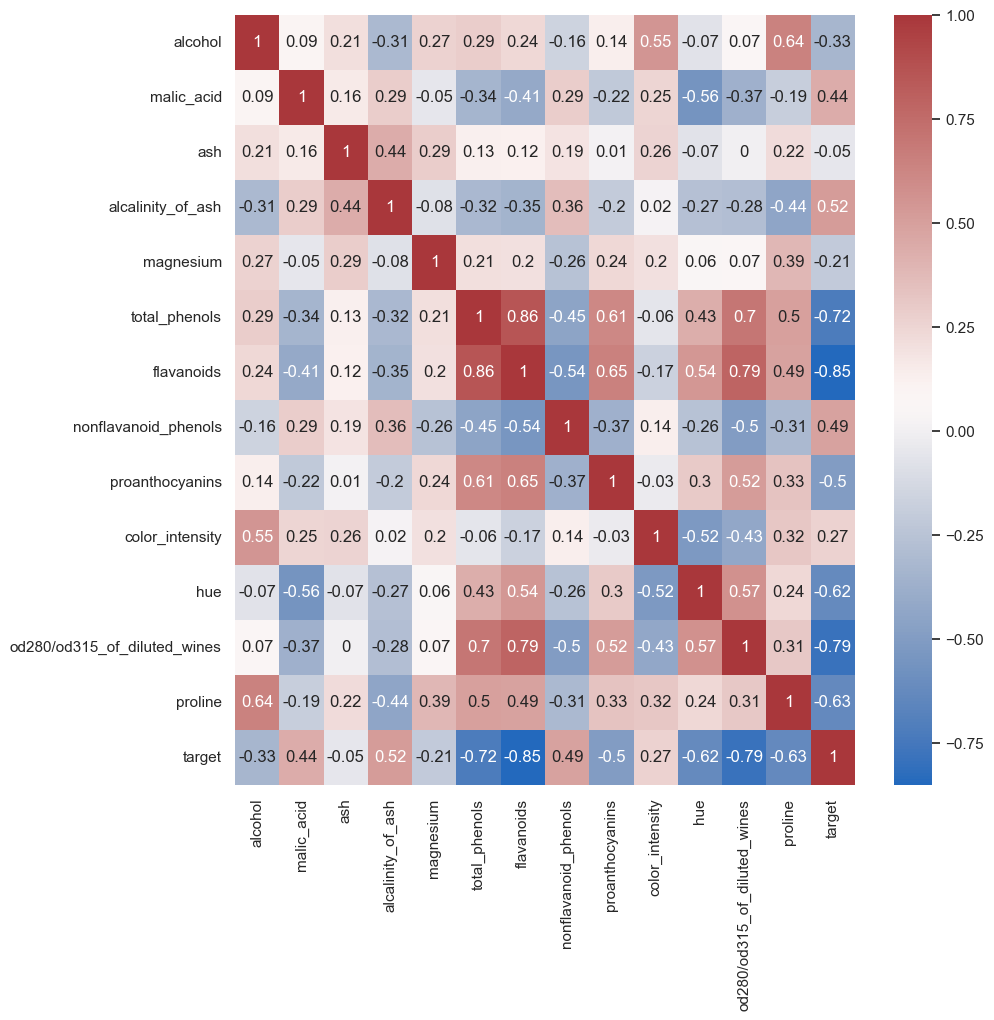

In [4]:
sns.set(rc={"figure.figsize":(10, 10)})
# Choose a diverging color palette!
sns.heatmap(wine_corrs, annot = True, cmap="vlag")
plt.show()
plt.close()

Now let's go one step beyond correlation and actually model the relationship between housing value and some of it's predictors. 

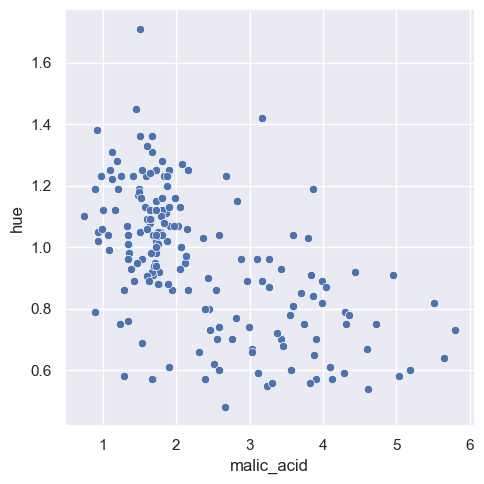

In [6]:
sns.relplot(data = wine_df, x = "malic_acid", y = "hue");

We will model "hue" **as a function of** "malic acid", represented as $hue \sim MalicAcid$ or more generally $y \sim x$ 

If we are modeling "hue" as a linear function of "malic acid", then the model will take the following form (with no intercept):

$$y = \theta_1x$$

$$hue = \theta_1*MalicAcid $$

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept = False)
wine_reg = model.fit(wine_df[["malic_acid"]], wine_df["hue"])

Note that we pass our predictors (the first argument) as a **2-dimensional array**. This is because we can have multiple predictors, so sklearn expects its x arguments as a matrix, even if there's only a single predictor.

In [8]:
wine_df[["malic_acid"]]

,malic_acid
0,1.71
1,1.78
2,2.36
3,1.95
4,2.59
...,...
173,5.65
174,3.91
175,4.28
176,2.59


Extract model statistics

In [9]:
print(f"B_1 = {wine_reg.coef_}")

B_1 = [0.31262129]


In [10]:
xs = np.linspace(np.min(wine_df['malic_acid']), np.max(wine_df['malic_acid']), 100)

b1 = wine_reg.coef_

preds = b1*xs

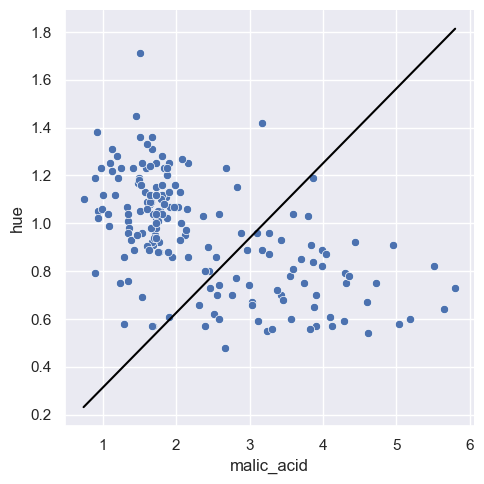

In [11]:
sns.relplot(data = wine_df, x = "malic_acid", y = "hue")
sns.lineplot(x = xs, y =  preds, c = "black");

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept = True)
wine_reg = model.fit(wine_df[["malic_acid"]], wine_df["hue"])

In [13]:
print(f"B_0 = {wine_reg.intercept_}")
print(f"B_1 = {wine_reg.coef_}")

B_0 = 1.2257623220512208
B_1 = [-0.11484284]


In [14]:
b0 = wine_reg.intercept_
b1 = wine_reg.coef_

preds = b0 + b1*xs

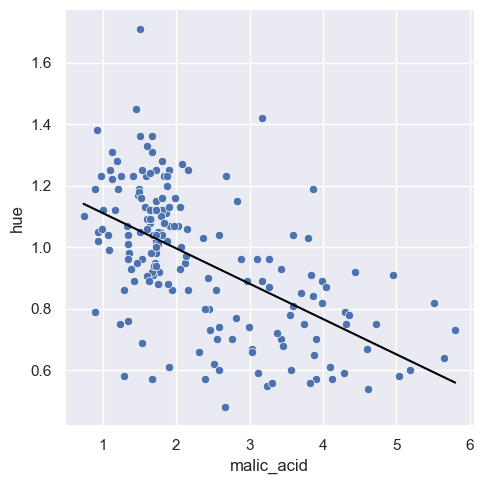

In [15]:
sns.relplot(data = wine_df, x = "malic_acid", y = "hue")
sns.lineplot(x = xs, y =  preds, c = "black");

Adding a second parameter, the intercept (sometimes called the bias) gave our model the flexibility it needed to fit the data well.

Plot the residuals plot and evaluate quality of fit.

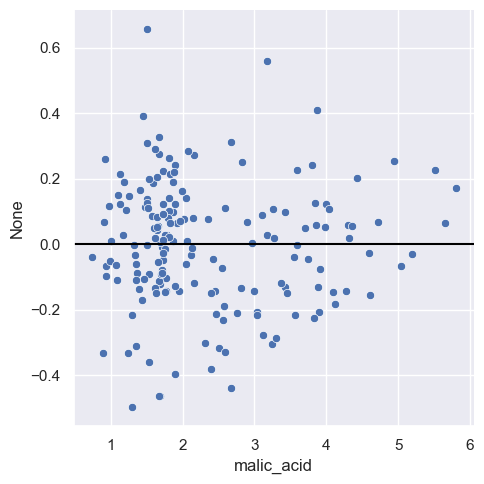

In [16]:
preds = b0 + b1*wine_df["malic_acid"]

sns.relplot(x = wine_df["malic_acid"], y = wine_df["hue"] - preds)
plt.axhline(y = 0, c = "black");

Some other packages that are specifically built for applying these models statistically, like statsmodels, give nicer summaries of model coefficiences and statistics. 

In [17]:
import statsmodels.api as sm

X = wine_df[['hue']]
X = sm.add_constant(X)

sm_model = sm.OLS(wine_df['malic_acid'], X).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:             malic_acid   R-squared:                       0.315
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     80.95
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           3.65e-16
Time:                        20:02:34   Log-Likelihood:                -238.11
No. Observations:                 178   AIC:                             480.2
Df Residuals:                     176   BIC:                             486.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9630      0.300     16.538      0.0

Now we can create our line to plot from the model

We can also use `.predict` to predict values from the model without needing to do the math ourselves.

In [18]:
preds = wine_reg.predict(xs[:, np.newaxis])

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


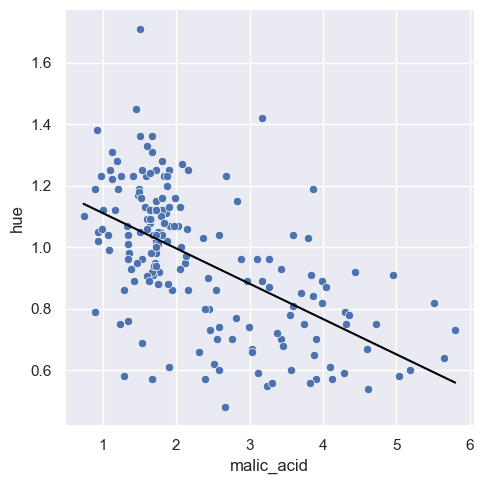

In [19]:
sns.relplot(data = wine_df, x = "malic_acid", y = "hue")
sns.lineplot(x = xs, y = preds, color = "black")
plt.show()
plt.close()

#### Multiple regression

The simple linear regression looks like a fairly good model. However, one thing that's obvious from our pairs/correlation plots is that there are other variables correlated with median value as well. Maybe we should try a multiple regression?

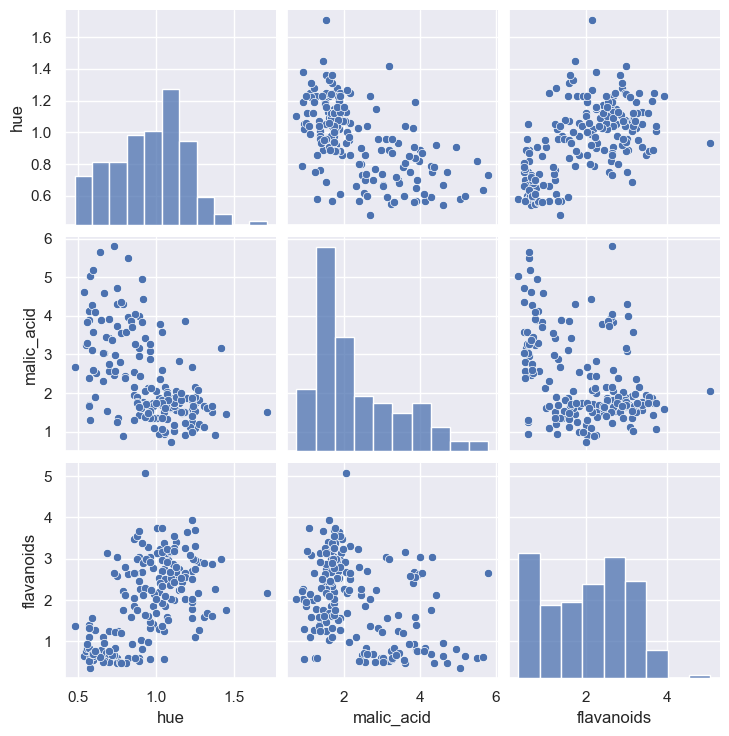

In [20]:
sns.pairplot(wine_df[["hue", "malic_acid",  "flavanoids"]])
plt.show()
plt.close()

Flavanoids also appear correlated with hue. Perhaps including flavanoids as an additional predictor will improve the model. 

In [21]:
wine_df[['malic_acid', 'flavanoids']].corr().round(2)

,malic_acid,flavanoids
malic_acid,1.00,-0.41
flavanoids,-0.41,1.00


In [22]:
model = LinearRegression()
mult_reg = model.fit(wine_df[['malic_acid', 'flavanoids']], wine_df['hue'])

$$y = \theta_0 + \theta_1x_1 + \theta_2x_2$$

In [23]:
print(f"B_0 = {mult_reg.intercept_}")
print(f"B_1 (RM) = {mult_reg.coef_[0]}")
print(f"B_2 (LSTAT) = {mult_reg.coef_[1]}")

B_0 = 0.977051097118063
B_1 (RM) = -0.08319356891470542
B_2 (LSTAT) = 0.08612334713198232


$$y = 0.98 + -0.08x_1 + 0.09x_2$$

Also look at the $R^2$:

In [28]:
print(f"R^2 = {mult_reg.score(wine_df[['malic_acid', 'flavanoids']], wine_df['hue'])}")

R^2 = 0.4327714186259912


Compare to the simple linear model

In [29]:
print(f"R^2 = {wine_reg.score(wine_df[['malic_acid']], wine_df['hue'])}")

R^2 = 0.31505285011385453


Based on our R-squared, the multiple regression model seems to explain about 12% more variation in the data compared to our univariate regression. We could also compare them with MSE or RMSE. 

In [30]:
y_slr = wine_reg.predict(wine_df[["malic_acid"]])
y_mult = mult_reg.predict(wine_df[['malic_acid', 'flavanoids']]) 

In [31]:
from sklearn.metrics import mean_squared_error

mean_squared_error(wine_df["hue"], y_slr, squared = False)

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
mean_squared_error(wine_df["hue"], y_mult, squared = False)

Clearly the multiple regression best fits our data, and leads to lower loss **when predicting values the model was trained on**.

**Let's reformat the model in an OLS fashion**

The model, reformulated with matrix notation: 

$$\hat{Y} = X\cdot\Theta$$

Remember, where $p$ is the number of predictors and $n$ is the number of observations: $\hat{Y}$ is a vector of $n$ predictions, $X$ is a $p \times n$ design matrix of $p$ columns and $n$ rows, and $\Theta$ is a vector of $p+1$ parameters. The + 1 comes from the addition of an intercept or *bias* term to the model.

In [ ]:
X = wine_df[["malic_acid","flavanoids"]]
X["bias"] = 1
X.head()

In [ ]:
params = np.array([mult_reg.coef_[0], mult_reg.coef_[1], mult_reg.intercept_])
params

We're using sklearn's parameters, but we could find the parameters ourselves using the normal equation:

$$\hat{\theta} = \left( \mathbb{X}^T \mathbb{X} \right)^{-1} \mathbb{X}^T \mathbb{Y}$$

In [ ]:
Y = wine_df["hue"]

params_normal_equation = np.linalg.inv(X.T @ X) @ X.T @ Y
params_normal_equation.values

Now attain predictions by taking the dot product of our matrix of predictors and their best-fit parameters.

In [ ]:
Y_hat = X @ params
Y_hat[0:5]

Same predictions as before

In [ ]:
y_mult[0:5]

Let's see what our multiple regression looks like in our variable space.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(wine_df['malic_acid'], wine_df['flavanoids'], wine_df['hue'], marker='.', color='red', s = 50)
ax.set_xlabel("malic_acid")
ax.set_ylabel("flavanoids")
ax.set_zlabel("hue")

In [ ]:
xx, yy = np.meshgrid(range(6), range(5))
zz = (params[2] + params[0] * xx + params[1] * yy)

In [ ]:
fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

ax.scatter(wine_df['malic_acid'], wine_df['flavanoids'], wine_df['hue'], marker='.', color='red')
ax.set_xlabel("malic_acid")
ax.set_ylabel("flavanoids")
ax.set_zlabel("hue")

ax.plot_surface(xx,yy,zz, alpha=0.2, color = "blue")

plt.show(fig)
plt.close()

#### Wine color qualitatively

In [ ]:
wine_df["color"] = 1
wine_df["color"][wine_df["hue"] < 1] = 0

In [ ]:
model = LinearRegression()
c_reg = model.fit(wine_df[['malic_acid']], wine_df['color'])
preds = c_reg.predict(xs[:, np.newaxis])

sns.relplot(x = wine_df["malic_acid"], y = wine_df["color"])
sns.lineplot(x = xs, y = preds, color = "red")
plt.ylim(-0.25,1.25)
plt.show()
plt.close()